In [2]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/2025-01.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809775 entries, 0 to 1809774
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Genero_Usuario         object 
 1   Edad_Usuario           float64
 2   Bici                   int64  
 3   Ciclo_Estacion_Retiro  object 
 4   Fecha_Retiro           object 
 5   Hora_Retiro            object 
 6   Ciclo_EstacionArribo   object 
 7   Fecha_Arribo           object 
 8   Hora_Arribo            object 
dtypes: float64(1), int64(1), object(7)
memory usage: 124.3+ MB


In [5]:
df['FechaHora_Arribo'] = pd.to_datetime(df['Fecha_Arribo'].astype(str) + ' ' + df['Hora_Arribo'].astype(str), dayfirst=True)
df['FechaHora_Retiro'] = pd.to_datetime(df['Fecha_Retiro'].astype(str) + ' ' + df['Hora_Retiro'].astype(str), dayfirst=True)


In [6]:
df['Fecha_Retiro'] = pd.to_datetime(df['Fecha_Retiro'],format='%d/%m/%Y')
df['Fecha_Arribo'] = pd.to_datetime(df['Fecha_Arribo'],format='%d/%m/%Y')

In [7]:
df['Dia_Retiro'] = df['Fecha_Retiro'].dt.day_name()
df['Dia_Arribo'] = df['Fecha_Arribo'].dt.day_name()

In [8]:
df['HoraCorta_Arribo'] = df['FechaHora_Arribo'].dt.hour
df['HoraCorta_Retiro'] = df['FechaHora_Retiro'].dt.hour

In [9]:
df.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,FechaHora_Arribo,FechaHora_Retiro,Dia_Retiro,Dia_Arribo,HoraCorta_Arribo,HoraCorta_Retiro
0,M,26.0,5180930,568,2024-12-31,23:57:02,572,2025-01-01,00:00:03,2025-01-01 00:00:03,2024-12-31 23:57:02,Tuesday,Wednesday,0,23
1,F,54.0,3653953,283,2024-12-31,23:51:40,596,2025-01-01,00:00:41,2025-01-01 00:00:41,2024-12-31 23:51:40,Tuesday,Wednesday,0,23
2,M,38.0,7511322,034,2024-12-31,23:48:36,064,2025-01-01,00:00:59,2025-01-01 00:00:59,2024-12-31 23:48:36,Tuesday,Wednesday,0,23
3,M,41.0,3804572,258,2024-12-31,23:54:11,023,2025-01-01,00:01:08,2025-01-01 00:01:08,2024-12-31 23:54:11,Tuesday,Wednesday,0,23
4,M,35.0,3848405,043,2024-12-31,23:35:28,126,2025-01-01,00:01:17,2025-01-01 00:01:17,2024-12-31 23:35:28,Tuesday,Wednesday,0,23


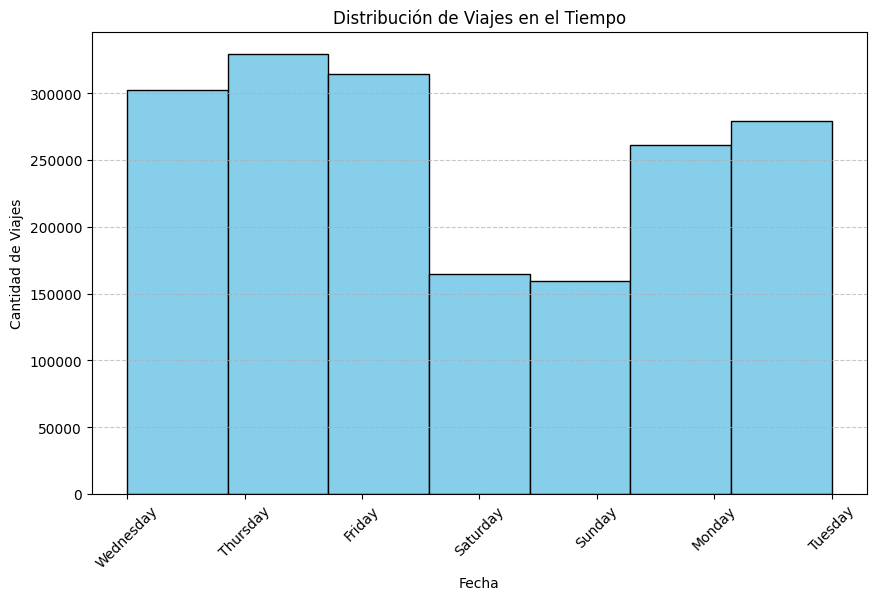

In [10]:
plt.figure(figsize=(10, 6))

# Creamos el histograma
# 'bins' define cuántas barras quieres ver (ej. 30 barras para un mes)
plt.hist(df['Dia_Arribo'], bins=7, color='skyblue', edgecolor='black')

plt.title('Distribución de Viajes en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45) # Rotamos las fechas para que se lean bien
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Wednesday'),
  Text(1, 0, 'Thursday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Saturday'),
  Text(4, 0, 'Sunday'),
  Text(5, 0, 'Monday'),
  Text(6, 0, 'Tuesday')])

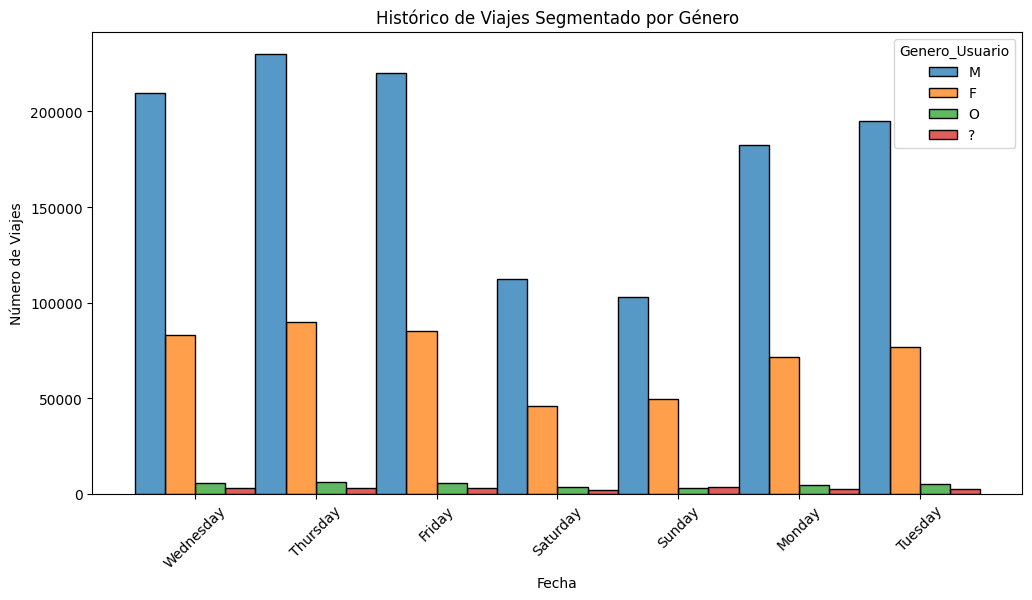

In [19]:
import seaborn as sns

plt.figure(figsize=(12, 6))

# 'hue' divide las barras por la columna de género
sns.histplot(data=df, x='Dia_Arribo', hue='Genero_Usuario', multiple='dodge', bins=40)

plt.title('Histórico de Viajes Segmentado por Género')
plt.xlabel('Fecha')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=45)